In [1]:
import os
import sys
import time
import json
import random
import argparse
from pathlib import Path

import torch

# Repo setup
repo_root = "/scratch/jq2uw/MME/instruct_vlm_edit"
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

from argparse import Namespace
from pathlib import Path
import torch

from revlm.config_utils import configure_args
from revlm.run.edit import run_edit

editor_name = "ike_chain"
# === Change this to test different samples ===
example_idx = 3


In [2]:
# Project root
project_root = Path("/scratch/jq2uw/MME/instruct_vlm_edit")

# Build test paths from args (no hardcoding)
args = Namespace(
    config="revlm/config/config.yaml",
    editor=editor_name,
    model_name="qwen3",
    dataset_name="aokvqa",
    task="mc",
    batch_size=1,
    split="all",
    rationale=False,
    cot=False,
    subsample=5,  # small for testing
    overwrite=True,
)

args.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
config = configure_args(args, config_path=args.config)
config.subsample = args.subsample



Task evaluation metrics will be saved to results/te/ike_chain/Qwen3-VL-8B-Instruct/aokvqa
Edit evaluation metrics will be saved to results/ee/ike_chain/Qwen3-VL-8B-Instruct/aokvqa
Predictions will be saved to results/pred/Qwen3-VL-8B-Instruct/aokvqa
Post-edit predictions will be saved to results/pred_postedit/ike_chain/Qwen3-VL-8B-Instruct/aokvqa
Unified filename to save: mc_all_sub5.json


## Step 2: Load Model & Editor


In [3]:
from revlm.models import VQAModel
from revlm.editors import IKE_CHAIN
from revlm.dataset.datasets import VQADataset

# Load model
vlm = VQAModel(config)
print(f"Model loaded: {type(vlm.model).__name__}")

# Load editor
editor = IKE_CHAIN(config, vlm)
print(f"Editor loaded: top_k_patches={editor.top_k_patches}")

# Load dataset
edit_ds = VQADataset(config)
edit_ds.set_dataloader()
if config.subsample and len(edit_ds) > config.subsample:
    edit_ds.data = random.sample(edit_ds.data, config.subsample)
print(f"Dataset: {len(edit_ds.data)} samples")


Model loaded: Qwen3VLForConditionalGeneration
Editor loaded: top_k_patches=3
Dataset: 5 samples


## Step 3-4: Visualize Augmentation and Patchification


Question: What does the spindle across from the cordless phone hold?
Answer: cds
COT: The image shows a spindle and a cordless phone. The spindle is located across from the cordless phone. There are discs sitting in a container on the spindle....

s1: The image shows a spindle and a cordless phone.
[Augmenter] Loading Qwen/Qwen2.5-1.5B-Instruct...


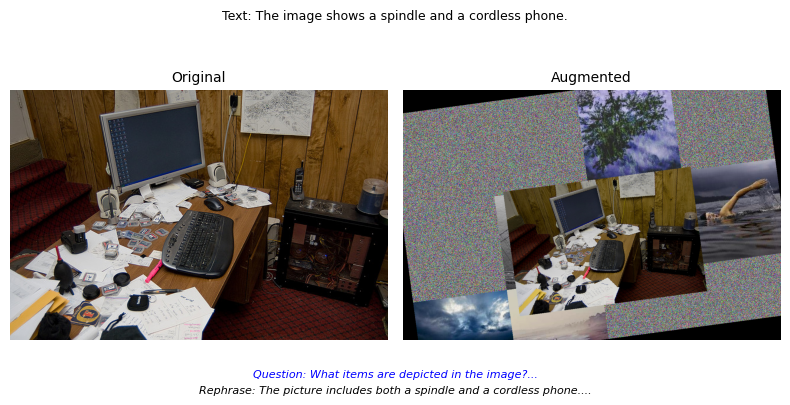

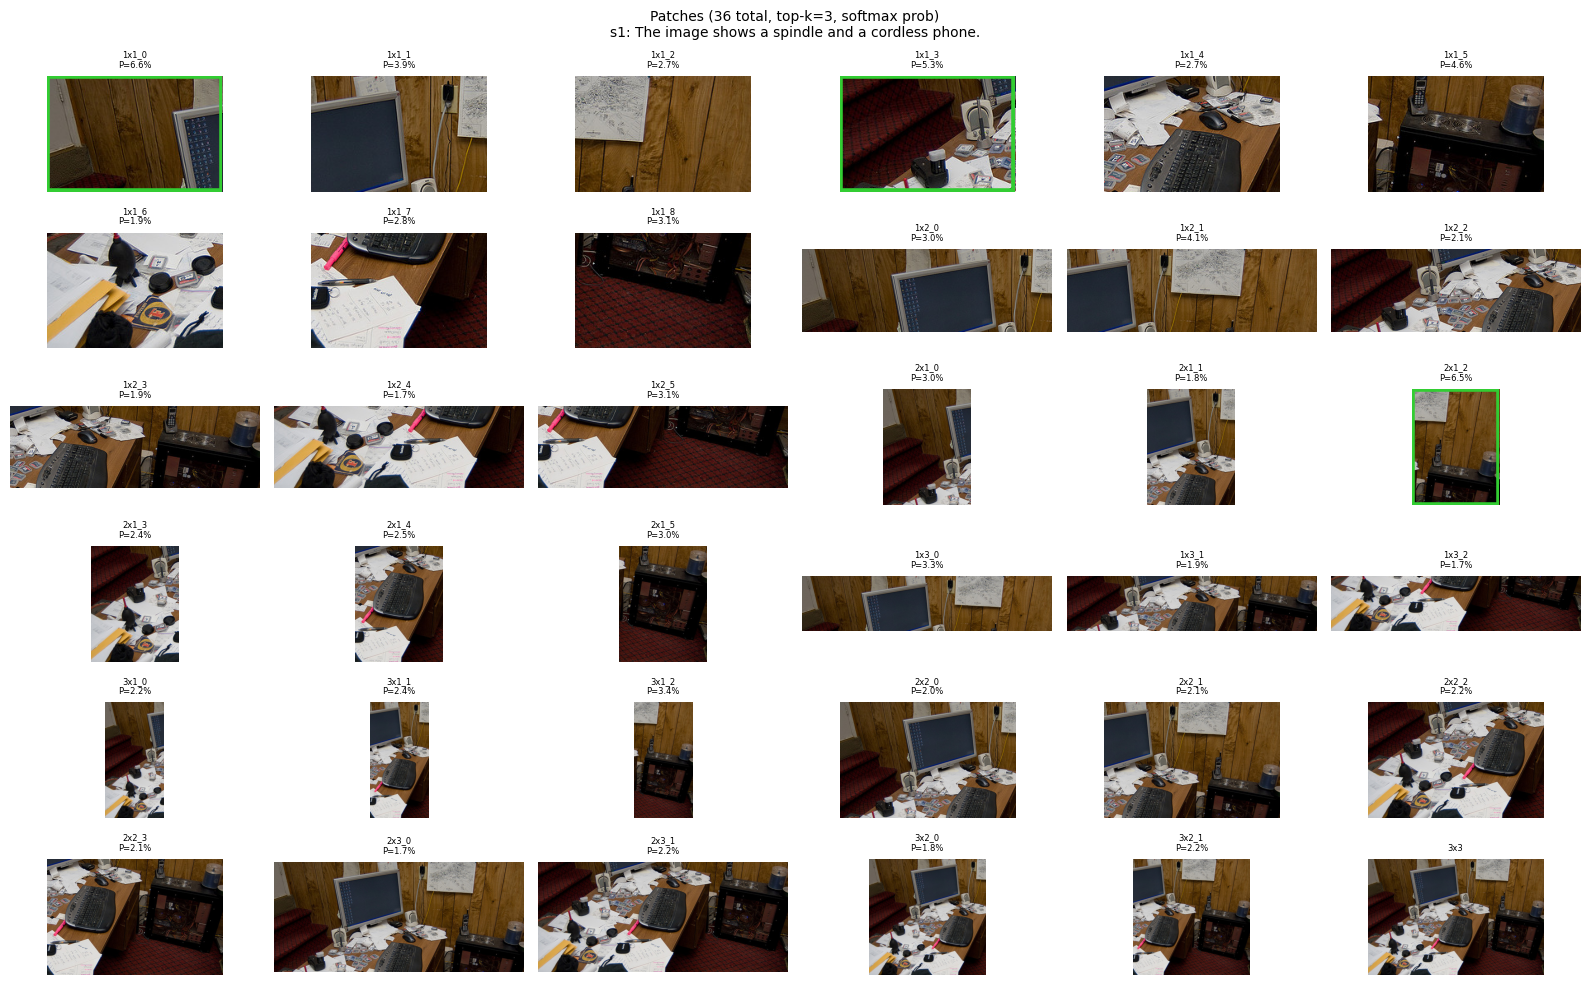

In [4]:
# Pick a sample
ex = edit_ds.data[example_idx]
print(f"Question: {ex['question']}")
print(f"Answer: {ex.get('answer', ex.get('target', ''))}")
print(f"COT: {ex.get('cot', ex.get('rationale', ''))[:200]}...")

# Get first sentence (s1)
import re
cot = ex.get('cot') or ex.get('rationale') or ''
sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", cot.strip()) if s.strip()]
s1 = sents[0] if sents else ""
print(f"\ns1: {s1}")

# Visualize augmentation (mosaic background + transforms)
editor.augmenter.visualize(ex['image'], text=s1, use_mosaic=True)

# Visualize patches (highlights top-k selected by s1 likelihood)
editor.visualize_patches(ex['image'], s1=s1)


## Step 5: Add Edits to Codebook


In [5]:
# Add edits to codebook
editor.edit(config, edit_ds=edit_ds)

# View stats
stats = editor.get_stats()
print("\nCodebook Stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")


[IKE_PATCH] edit 1/5...

[IKE_PATCH] edit 5/5...[IKE_PATCH] +5 edits (k=3, r=augment(n=1)), 0->84 keys, 0.3 MB
[IKE_PATCH] applied facts to 5/5 examples

Codebook Stats:
  num_keys: 84
  num_orig_keys: 21
  num_patch_keys: 63
  num_question_keys: 20
  num_rationale_keys: 64
  num_image_only_keys: 0
  num_edits: 5
  top_k_patches: 3
  image_only_retrieval: False
  emb_size_mb: 0.3076171875
  avg_radius: 86.38072204589844
  min_radius: 63.98926544189453
  max_radius: 114.24726104736328


## Step 6: Visualize Codebook Network


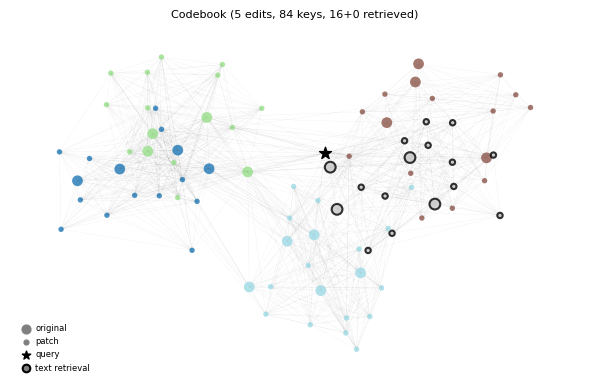

In [6]:
# # Plot codebook network (color by edit, size by original vs patch)
# editor.plot_codebook()

# Plot with a query point
test_ex = edit_ds.data[example_idx]
editor.plot_codebook(query_img=test_ex['image'], query_text=test_ex['question'])


## Step 7: Test Retrieval


In [7]:
# Test retrieval on training sample (should retrieve)
ex = edit_ds.data[example_idx]
facts = editor._retrieve(ex['image'], ex['question'])
print(f"Query: {ex['question']}")
print(f"Retrieved {len(facts)} facts:")
for i, f in enumerate(facts):
    print(f"  [{i}] {f[:100]}...")


Query: What does the spindle across from the cordless phone hold?
Retrieved 3 facts:
  [0] The image shows a spindle and a cordless phone....
  [1] The answer to 'What does the spindle across from the cordless phone hold?' is cds....
  [2] The spindle is located across from the cordless phone....


## Step 8: Generate with Retrieved Context


In [8]:
# Apply to dataset (prepends retrieved facts to prompts)
editor.apply_to_dataset(edit_ds)

# Check augmented prompt
ex = edit_ds.data[example_idx]
print(f"Original prompt: {ex.get('prompt_orig', 'N/A')}")
print(f"Human rationale: {ex.get('rationale', 'N/A')}")
print(f"proxy Human COT: {ex.get('cot', 'N/A')}")
print(f"Augmented prompt: {ex['prompt']}")

# Generate answer
answer = vlm.generate([ex['image']], [ex['prompt']], max_new_tokens=64)
print(f"\nGenerated: {answer[0]}")
print(f"Gold: {ex.get('gold', {}).get('label', '')}")


[IKE_PATCH] applied facts to 5/5 examples
Original prompt: What does the spindle across from the cordless phone hold?
Human rationale: The discs are sitting in the container.
proxy Human COT: The image shows a spindle and a cordless phone. The spindle is located across from the cordless phone. There are discs sitting in a container on the spindle.
Augmented prompt: The image shows a spindle and a cordless phone. The answer to 'What does the spindle across from the cordless phone hold?' is cds. The spindle is located across from the cordless phone. What does the spindle across from the cordless phone hold?

Generated: Based on the image provided, the spindle across from the cordless phone holds **CDs**.The spindle is the black, cylindrical object on the desk, located to the left of the computer monitor. It is filled with what appear to be compact discs (CDs). The cordless phone is on the right side
Gold: cds


## Step 9: Test with Generality Evaluation Samples


In [9]:
# Load generality evaluation data for ALL samples (run once)
from revlm.metrics.utils.t_gen import get_t_gen_input
from revlm.metrics.utils.i_gen import get_i_gen_input
from revlm.metrics.utils.r_gen import get_r_gen_input
from PIL import Image

dataset_name = config.experiment.dataset_name

related_texts = get_t_gen_input(dataset_name, edit_ds)
related_images = get_i_gen_input(dataset_name, edit_ds)
related_r_gen_df = get_r_gen_input(dataset_name, edit_ds)

print(f"Loaded generality data for {len(edit_ds.data)} samples")
print(f"Text gen UIDs: {len(related_texts)}, Image gen UIDs: {len(related_images)}, Rationale gen rows: {len(related_r_gen_df)}")


Loaded generality data for 5 samples
Text gen UIDs: 5, Image gen UIDs: 5, Rationale gen rows: 34


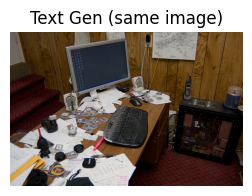

[example_idx=3] Original Q: What does the spindle across from the cordless phone hold?
Paraphrased Q: What is contained in the spindle located opposite the cordless phone?
Retrieved 3 facts:
  [0] The image shows a spindle and a cordless phone....
  [1] The answer to 'What does the spindle across from the cordless phone hold?' is cds....
  [2] The spindle is located across from the cordless phone....


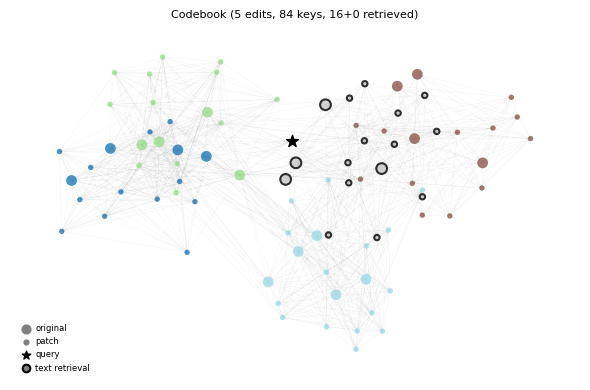

In [10]:
# =============================================

# Text Generality: same image, paraphrased question
import matplotlib.pyplot as plt
ex = edit_ds.data[example_idx]
uid = str(ex["uid"])
if uid in related_texts:
    t_gen_q = related_texts[uid][0]
    img = ex["image"] if isinstance(ex["image"], Image.Image) else Image.open(ex["image"]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(img); plt.axis('off'); plt.title("Text Gen (same image)"); plt.show()
    print(f"[example_idx={example_idx}] Original Q: {ex['question']}")
    print(f"Paraphrased Q: {t_gen_q}")
    facts = editor._retrieve(img, t_gen_q)
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=img, query_text=t_gen_q)
else:
    print(f"No text generality data for uid={uid}")


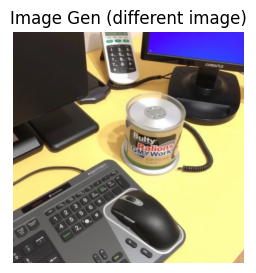

Question: What does the spindle across from the cordless phone hold?
Image: data/related_image/aokvqa/train_436963/flux_0.png


Retrieved 3 facts:
  [0] The image shows a spindle and a cordless phone....
  [1] The answer to 'What does the spindle across from the cordless phone hold?' is cds....
  [2] The spindle is located across from the cordless phone....


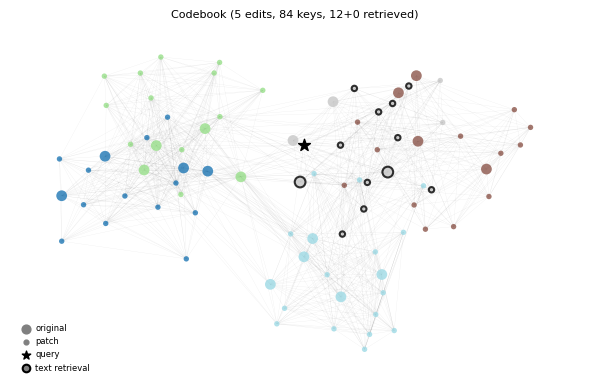

In [11]:
# Image Generality: same question, different image
ex = edit_ds.data[example_idx]
uid = str(ex["uid"])
if uid in related_images:
    i_gen_img = Image.open(related_images[uid][0]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(i_gen_img); plt.axis('off'); plt.title("Image Gen (different image)"); plt.show()
    print(f"Question: {ex['question']}")
    print(f"Image: {related_images[uid][0]}")
    facts = editor._retrieve(i_gen_img, ex["question"])
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=i_gen_img, query_text=ex["question"])
else:
    print(f"No image generality data for uid={uid}")


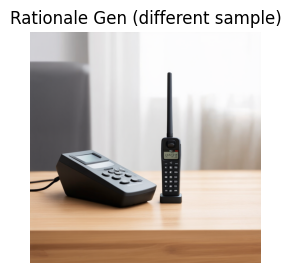

Question: What objects are shown in the image?
Image: data/r_gen/image/aokvqa/8025_1.png


Retrieved 1 facts:
  [0] The image shows a spindle and a cordless phone....


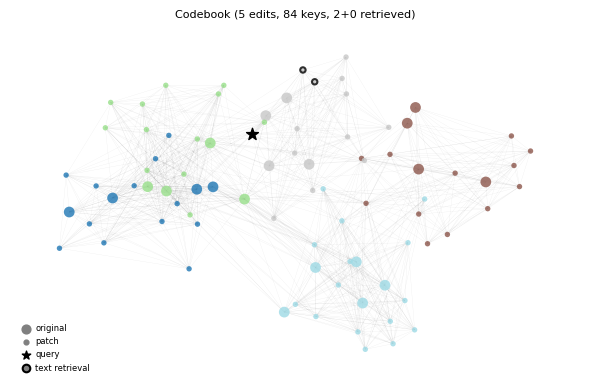

In [12]:
# Rationale Generality: different sample from same edit
ex = edit_ds.data[example_idx]
uid = str(ex["uid"])
r_gen_for_uid = related_r_gen_df[related_r_gen_df["uid"] == uid]
if len(r_gen_for_uid) > 0:
    row = r_gen_for_uid.iloc[0]
    # row['question'] = "Does the image show a spindle and a cordless phone?"
    r_gen_img = Image.open(row["image_path"]).convert("RGB")
    plt.figure(figsize=(3,3)); plt.imshow(r_gen_img); plt.axis('off'); plt.title("Rationale Gen (different sample)"); plt.show()
    print(f"Question: {row['question']}")
    print(f"Image: {row['image_path']}")
    facts = editor._retrieve(r_gen_img, row["question"])
    print(f"Retrieved {len(facts)} facts:")
    for i, f in enumerate(facts):
        print(f"  [{i}] {f[:100]}...")
    editor.plot_codebook(query_img=r_gen_img, query_text=row["question"])
else:
    print(f"No rationale generality data for uid={uid}")
